In [13]:
import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

## Configuration

In [14]:
INTERFERENCE_DIR = Path("interference")

# Select which interference run to load (filename without .json, or None for latest)
SELECTED_RUN = "interf2"

# Optional: a non-interference baseline run from data/runs/ for comparison
BASELINE_RUN = "run41"
RUNS_DIR = Path("runs")

# Display options
SHOW_REBALANCE = False
SHOW_OPTIMUM = True
SHOW_INTERFERENCE_REGIONS = True  # shade background by interference step

In [15]:
# Load interference run
if SELECTED_RUN:
    interf_path = INTERFERENCE_DIR / f"{SELECTED_RUN}.json"
else:
    interf_files = sorted(INTERFERENCE_DIR.glob("*.json"))
    interf_path = interf_files[-1] if interf_files else None

with open(interf_path) as f:
    interf_data = json.load(f)

print(f"Loaded: {interf_path.stem}")

# Load baseline if specified
baseline_data = None
if BASELINE_RUN:
    baseline_path = RUNS_DIR / f"{BASELINE_RUN}.json"
    if baseline_path.exists():
        with open(baseline_path) as f:
            baseline_data = json.load(f)
        print(f"Baseline: {BASELINE_RUN}")
    else:
        print(f"Baseline not found: {baseline_path}")

Loaded: interf2
Baseline: run41


## Run Summary

In [16]:
meta = interf_data.get("meta", {})
schedule_steps = meta.get("schedule_steps", [])
step_duration = meta.get("step_duration", "?")

print(f"Schedule: {meta.get('schedule')} ({len(schedule_steps)} steps × {step_duration}s)")
print(f"Steps: {schedule_steps}")
print(f"Optimizer: {meta.get('optimizer')}, kwargs: {meta.get('optimizer_kwargs')}")
print()

for model, result in interf_data["results"].items():
    batches = result.get("batches", [])
    rps = result.get("requests_per_second", 0)
    timed = [b for b in batches if "timing" in b]
    rebalances = sum(1 for b in batches if b.get("rebalance", {}).get("did_rebalance", False))
    at_optimum = sum(1 for b in batches if b.get("rebalance", {}).get("at_optimum", False))
    if timed:
        times = [b["timing"]["end"] - b["timing"]["start"] for b in timed]
        wall = timed[-1]["timing"]["end"] - timed[0]["timing"]["start"]
        print(f"{model}: rps={rps:.2f}, batches={len(timed)}, rebalances={rebalances}, at_optimum={at_optimum}")
        print(f"  forward: avg={np.mean(times):.3f}s, min={min(times):.3f}s, max={max(times):.3f}s, wall={wall:.0f}s")
    else:
        print(f"{model}: no timing data")

# Baseline comparison
if baseline_data:
    print(f"\n--- Baseline ({BASELINE_RUN}) ---")
    for model, result in baseline_data["results"].items():
        rps = result.get("requests_per_second", 0)
        print(f"  {model}: rps={rps:.2f}")

Schedule: gradient (4 steps × 120s)
Steps: [['idle', 0, 0], ['cpu_stress', 1, 19], ['cpu_stress', 2, 10], ['cpu_stress', 4, 0]]
Optimizer: TimeBasedShishaPipelineOptimizer, kwargs: {'deep_alpha': 5, 'sibling_alpha': 2, 'assignment_choice': 'rank_w', 'rebalance_interval': 3, 'tolerance': 0.02, 'optimum_tolerance': 0.08, 'optimum_escape_duration': 7}

conv_next: rps=22.66, batches=400, rebalances=400, at_optimum=4
  forward: avg=18.144s, min=16.156s, max=23.047s, wall=565s
conv_next_base: rps=18.86, batches=300, rebalances=300, at_optimum=0
  forward: avg=26.664s, min=22.187s, max=32.145s, wall=509s
efficientnet_b6: rps=1.99, batches=100, rebalances=100, at_optimum=0
  forward: avg=389.479s, min=378.907s, max=397.292s, wall=1607s
regnet_x_16gf: rps=10.97, batches=200, rebalances=200, at_optimum=0
  forward: avg=58.084s, min=40.758s, max=69.028s, wall=583s

--- Baseline (run41) ---
  conv_next: rps=32.78
  conv_next_base: rps=25.14
  efficientnet_b6: rps=5.53
  regnet_x_16gf: rps=18.41


In [ ]:
# One color per schedule step (indexed by position)
STEP_PALETTE = ["#66bb6a", "#ffb74d", "#ef5350", "#ab47bc", "#42a5f5", "#8d6e63"]

def get_interference_regions(interf_data, model):
    """Get interference step boundaries as wall-clock times from the interference log."""
    interf_log = interf_data.get("interference", {}).get(model, {})
    events = interf_log.get("events", [])
    if not events:
        return []

    regions = []
    current_bench = None
    current_start = None
    current_threads = 0

    for e in events:
        if e["event"] == "start":
            if current_bench is not None:
                regions.append((current_start, e["time"], current_bench, current_threads))
            current_bench = e["benchmark"]
            current_start = e["time"]
            current_threads = e.get("threads", 0)
        elif e["event"] == "stop" and e.get("benchmark") == "all":
            if current_bench is not None:
                regions.append((current_start, e["time"], current_bench, current_threads))
                current_bench = None

    return regions

def _step_label(name, threads, cores=None):
    """Human-readable label for a schedule step."""
    if name == "idle":
        return "Idle"
    cores_str = f", c{cores}" if cores else ""
    return f"{name} ({threads}t{cores_str})"

def draw_interference_boundaries(ax, regions, interf_data, xlim_mode="batch_index", batches=None):
    """Draw vertical lines at interference step boundaries with colored labels."""
    if not regions:
        return

    schedule_steps = interf_data.get("meta", {}).get("schedule_steps", [])
    added_labels = set()

    for region_i, (start_t, end_t, bench, threads) in enumerate(regions):
        color = STEP_PALETTE[region_i % len(STEP_PALETTE)]

        if region_i < len(schedule_steps):
            step = schedule_steps[region_i]
            cores = step[2] if len(step) > 2 else ""
            label = _step_label(step[0], step[1], cores)
        else:
            label = _step_label(bench, threads)

        if xlim_mode == "batch_index" and batches:
            x = 0
            for i, b in enumerate(batches):
                if "timing" in b and b["timing"]["start"] >= start_t:
                    x = i
                    break
        else:
            x = start_t

        ax.axvline(x, color=color, linestyle="--", linewidth=1.5, alpha=0.8,
                   label=label)

## Batch Times with Interference Regions

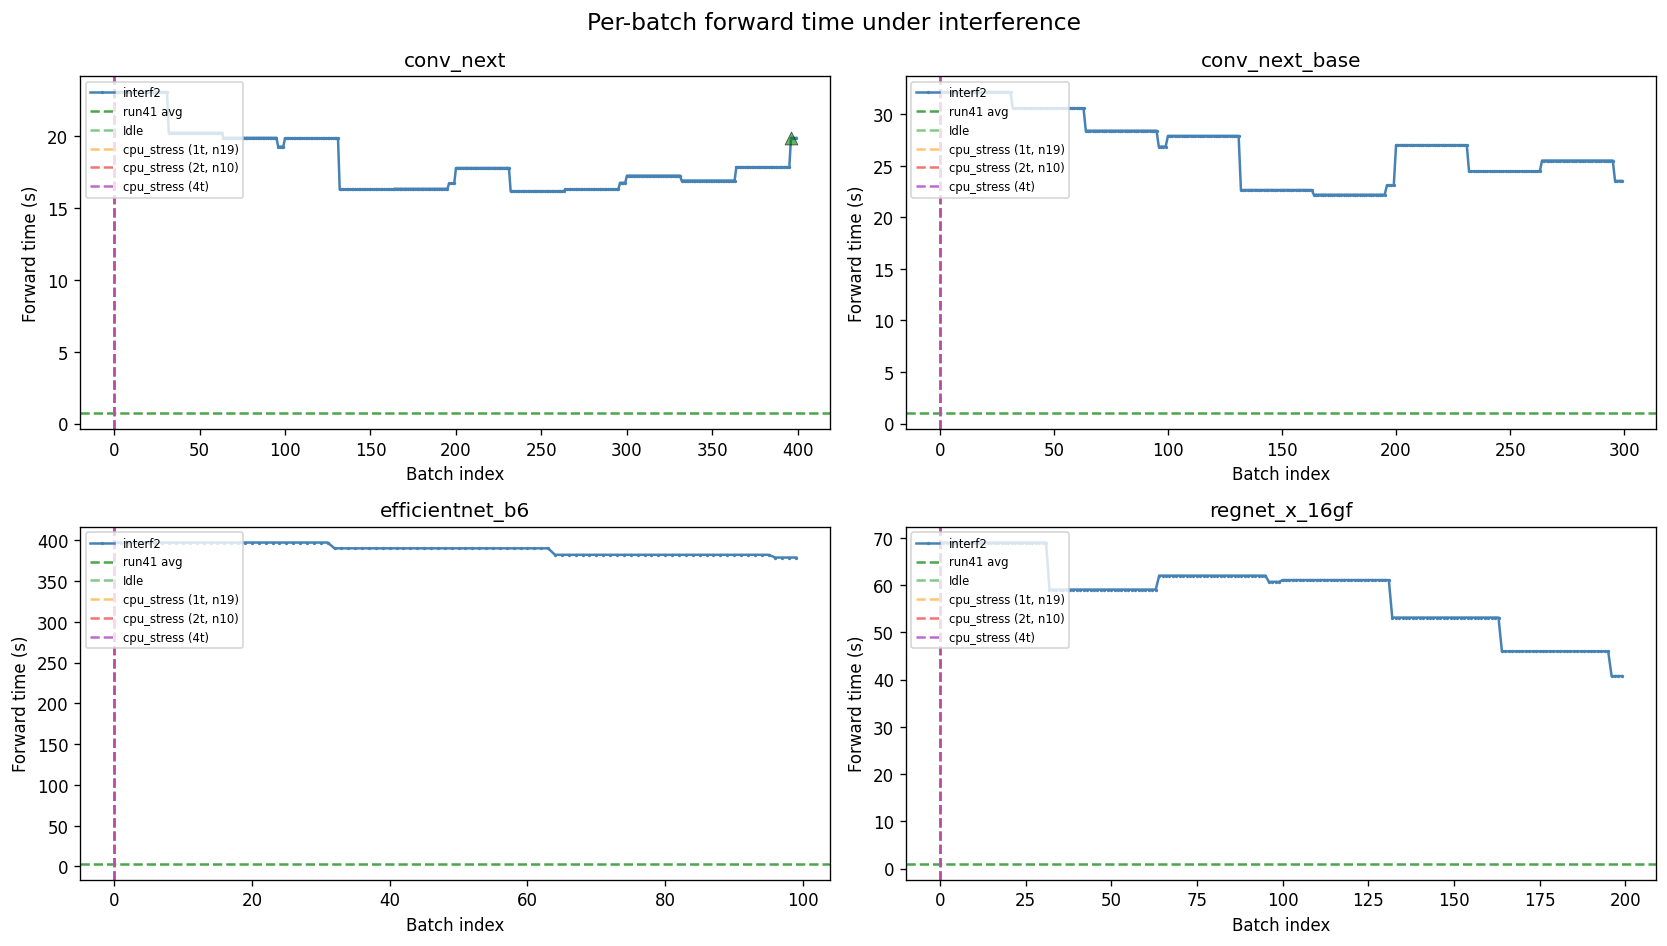

In [18]:
models = list(interf_data["results"].keys())
n_models = len(models)
cols = min(n_models, 2)
rows = math.ceil(n_models / cols)

fig, axes = plt.subplots(rows, cols, figsize=(7 * cols, 4 * rows), squeeze=False)

for idx, model in enumerate(models):
    ax = axes[idx // cols][idx % cols]
    result = interf_data["results"][model]
    batches = result.get("batches", [])
    timed = [b for b in batches if "timing" in b]
    elapsed = [b["timing"]["end"] - b["timing"]["start"] for b in timed]

    if not elapsed:
        ax.set_title(f"{model} (no data)")
        continue

    # Plot batch times
    ax.plot(range(len(elapsed)), elapsed, color="steelblue", marker=".", markersize=2,
            label=interf_path.stem)

    # Baseline mean as horizontal line
    if baseline_data and model in baseline_data.get("results", {}):
        bl_batches = baseline_data["results"][model].get("batches", [])
        bl_times = [b["timing"]["end"] - b["timing"]["start"] for b in bl_batches if "timing" in b]
        if bl_times:
            ax.axhline(np.mean(bl_times), color="green", linestyle="--", alpha=0.7,
                       label=f"{BASELINE_RUN} avg")

    # Interference step boundaries
    if SHOW_INTERFERENCE_REGIONS:
        regions = get_interference_regions(interf_data, model)
        draw_interference_boundaries(ax, regions, interf_data, xlim_mode="batch_index", batches=timed)

    # Optimum markers
    if SHOW_OPTIMUM:
        opt_flags = [b.get("rebalance", {}).get("at_optimum", False) for b in timed]
        enters = [i for i in range(len(opt_flags))
                  if opt_flags[i] and (i == 0 or not opt_flags[i-1])]
        leaves = [i-1 for i in range(1, len(opt_flags))
                  if not opt_flags[i] and opt_flags[i-1]]
        if enters:
            ax.scatter(enters, [elapsed[i] for i in enters], color="green", marker="^",
                       s=60, alpha=0.6, edgecolors="black", linewidths=0.5, zorder=5)
        if leaves:
            ax.scatter(leaves, [elapsed[i] for i in leaves], color="red", marker="v",
                       s=60, alpha=0.6, edgecolors="black", linewidths=0.5, zorder=5)

    ax.set_title(model)
    ax.set_xlabel("Batch index")
    ax.set_ylabel("Forward time (s)")
    ax.legend(fontsize="x-small", loc="upper left")

for idx in range(n_models, rows * cols):
    axes[idx // cols][idx % cols].set_visible(False)

fig.suptitle("Per-batch forward time under interference", fontsize=14)
fig.tight_layout()
plt.show()

## Throughput Comparison (RPS)

In [ ]:
# Per-step RPS: compute RPS for batches within each interference region
models = list(interf_data["results"].keys())
schedule_steps = interf_data["meta"].get("schedule_steps", [])
step_labels = []
for name, threads, cores in schedule_steps:
    if name == "idle":
        step_labels.append("idle")
    else:
        cores_str = f" c{cores}" if cores else ""
        step_labels.append(f"{name}({threads}t{cores_str})")

fig, ax = plt.subplots(figsize=(max(10, len(models) * 3), 5))

x = np.arange(len(models))
n_steps = len(step_labels)
bar_width = 0.8 / (n_steps + (1 if baseline_data else 0))

step_colors_list = ["#4caf50", "#ff9800", "#f44336", "#9c27b0", "#2196f3", "#795548"]

for step_i, step_label in enumerate(step_labels):
    rps_values = []
    for model in models:
        batches = interf_data["results"][model].get("batches", [])
        timed = [b for b in batches if "timing" in b]
        regions = get_interference_regions(interf_data, model)

        if step_i < len(regions):
            r_start, r_end = regions[step_i][0], regions[step_i][1]
            step_batches = [b for b in timed
                           if r_start <= b["timing"]["start"] < r_end]
            if len(step_batches) >= 2:
                wall = step_batches[-1]["timing"]["end"] - step_batches[0]["timing"]["start"]
                rps_values.append(len(step_batches) / wall if wall > 0 else 0)
            else:
                rps_values.append(0)
        else:
            rps_values.append(0)

    offset = (step_i - n_steps / 2 + 0.5) * bar_width
    color = step_colors_list[step_i % len(step_colors_list)]
    ax.bar(x + offset, rps_values, bar_width, label=step_label, color=color, alpha=0.8)

# Baseline bars
if baseline_data:
    bl_rps = []
    for model in models:
        if model in baseline_data.get("results", {}):
            bl_rps.append(baseline_data["results"][model].get("requests_per_second", 0))
        else:
            bl_rps.append(0)
    offset = (n_steps - n_steps / 2 + 0.5) * bar_width
    ax.bar(x + offset, bl_rps, bar_width, label=f"{BASELINE_RUN} (no interf)",
           color="green", alpha=0.5, edgecolor="black", linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha="right")
ax.set_ylabel("Requests per second")
ax.set_title("Throughput by interference level")
ax.legend(fontsize="small")
fig.tight_layout()
plt.show()

## Throughput Impact (%)

In [ ]:
# Show percentage throughput degradation relative to idle step
models = list(interf_data["results"].keys())
schedule_steps = interf_data["meta"].get("schedule_steps", [])

print(f"{'Model':<20}", end="")
for name, threads, cores in schedule_steps:
    label = "idle" if name == "idle" else f"{name}({threads}t)"
    print(f"{label:>20}", end="")
if baseline_data:
    print(f"{'baseline':>20}", end="")
print()
print("-" * (20 + 20 * len(schedule_steps) + (20 if baseline_data else 0)))

for model in models:
    batches = interf_data["results"][model].get("batches", [])
    timed = [b for b in batches if "timing" in b]
    regions = get_interference_regions(interf_data, model)

    step_rps = []
    for step_i in range(len(schedule_steps)):
        if step_i < len(regions):
            r_start, r_end = regions[step_i][0], regions[step_i][1]
            step_batches = [b for b in timed if r_start <= b["timing"]["start"] < r_end]
            if len(step_batches) >= 2:
                wall = step_batches[-1]["timing"]["end"] - step_batches[0]["timing"]["start"]
                step_rps.append(len(step_batches) / wall if wall > 0 else 0)
            else:
                step_rps.append(0)
        else:
            step_rps.append(0)

    idle_rps = step_rps[0] if step_rps and step_rps[0] > 0 else 1

    print(f"{model:<20}", end="")
    for rps in step_rps:
        if rps > 0:
            pct = (rps / idle_rps) * 100
            print(f"{rps:>10.2f} ({pct:>4.0f}%)", end="")
        else:
            print(f"{'N/A':>20}", end="")
    if baseline_data and model in baseline_data.get("results", {}):
        bl_rps = baseline_data["results"][model].get("requests_per_second", 0)
        pct = (bl_rps / idle_rps) * 100
        print(f"{bl_rps:>10.2f} ({pct:>4.0f}%)", end="")
    print()

## Optimizer State Under Interference

In [ ]:
models = list(interf_data["results"].keys())

for model in models:
    result = interf_data["results"][model]
    batches = result.get("batches", [])

    deep_gamma = [b.get("rebalance", {}).get("deep_gamma") for b in batches]
    sibling_gamma = [b.get("rebalance", {}).get("sibling_gamma") for b in batches]
    best_throughput = [b.get("rebalance", {}).get("best_throughput") for b in batches]

    if not any(v is not None for v in deep_gamma):
        continue

    opt_kwargs = interf_data.get("meta", {}).get("optimizer_kwargs", {})
    deep_alpha = opt_kwargs.get("deep_alpha", 5)

    combined = [
        (d or 0) + (s or 0) * deep_alpha
        if d is not None and s is not None else None
        for d, s in zip(deep_gamma, sibling_gamma)
    ]

    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    fig.suptitle(f"{model} — Optimizer State", fontsize=14)

    xs = range(len(batches))

    # Combined gamma
    axes[0].plot(xs, combined, color="steelblue", alpha=0.8, markersize=2)
    axes[0].set_ylabel("Combined gamma\n(deep + sibling * alpha)")

    # Best throughput
    axes[1].plot(xs, best_throughput, color="darkorange", alpha=0.8, markersize=2)
    axes[1].set_ylabel("Best throughput")
    axes[1].set_xlabel("Batch index")

    # Interference step boundaries on both subplots
    if SHOW_INTERFERENCE_REGIONS:
        regions = get_interference_regions(interf_data, model)
        timed = [b for b in batches if "timing" in b]
        for ax_i in axes:
            draw_interference_boundaries(ax_i, regions, interf_data, xlim_mode="batch_index", batches=timed)

    # Optimum enter/leave on both
    if SHOW_OPTIMUM:
        opt_flags = [b.get("rebalance", {}).get("at_optimum", False) for b in batches]
        enters = [i for i in range(len(opt_flags))
                  if opt_flags[i] and (i == 0 or not opt_flags[i-1])]
        leaves = [i-1 for i in range(1, len(opt_flags))
                  if not opt_flags[i] and opt_flags[i-1]]
        for ax_i in axes:
            for e in enters:
                ax_i.axvline(e, color="green", linestyle="-", alpha=0.3, linewidth=0.8)
            for l in leaves:
                ax_i.axvline(l, color="red", linestyle="-", alpha=0.3, linewidth=0.8)

    # Only show legend on first subplot to avoid duplication
    axes[0].legend(fontsize="small", loc="upper left")
    fig.tight_layout()
    plt.show()

## Forward Time Distribution per Interference Step

In [ ]:
models = list(interf_data["results"].keys())
schedule_steps = interf_data["meta"].get("schedule_steps", [])

fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 5), squeeze=False)

for idx, model in enumerate(models):
    ax = axes[0][idx]
    batches = interf_data["results"][model].get("batches", [])
    timed = [b for b in batches if "timing" in b]
    regions = get_interference_regions(interf_data, model)

    box_data = []
    box_labels = []

    for step_i, (name, threads, cores) in enumerate(schedule_steps):
        if step_i < len(regions):
            r_start, r_end = regions[step_i][0], regions[step_i][1]
            step_times = [b["timing"]["end"] - b["timing"]["start"]
                         for b in timed if r_start <= b["timing"]["start"] < r_end]
        else:
            step_times = []

        box_data.append(step_times if step_times else [0])
        label = "idle" if name == "idle" else f"{threads}t\nc{cores}"
        box_labels.append(label)

    bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True)
    colors = ["#4caf50", "#ff9800", "#f44336", "#9c27b0", "#2196f3", "#795548"]
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.5)

    ax.set_title(model)
    ax.set_ylabel("Forward time (s)" if idx == 0 else "")
    ax.set_xlabel("Interference step")

fig.suptitle("Forward time distribution by interference level", fontsize=14)
fig.tight_layout()
plt.show()